# **Durability emulator — PCE training**

This notebook **only** fits and validates the PCE. It reads the `dataset_unique_train` / `dataset_unique_val` files written by [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

CO₂ uses the published CMIP6/SSP table. Set `installation_year` and `co2_scenario` below.
The 100-year horizon must end no later than 2100. Regenerate datasets and retrain after changing the scenario; old polynomial results are not compatible.


## **1. Libraries**

In [8]:
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from functions import *
from UQpy.distributions import Uniform, JointIndependent

## **2. Random variables and fixed parameters**

Must match [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb). This only rebuilds the
distribution object and the filename tag, it draws no new samples.

In [9]:
fck_min = 20
fck_max = 50
rh_min  = 20
rh_max  = 80
cov_min = 15
cov_max = 60

cement_type         = 3
installation_year   = 1980
co2_scenario        = "SSP2-4.5"  # SSP1-2.6, SSP2-4.5, or SSP5-8.5
exposure_conditions = 2
n_latent_samples     = 2500     # must match stage 1 — it is the filename prefix
n_lambdas            = 4
max_degree           = 3        # maximum total degree of the PCE polynomial basis

fck_dist = Uniform(loc=fck_min, scale=fck_max - fck_min)
rh_dist  = Uniform(loc=rh_min, scale=rh_max - rh_min)
cov_dist = Uniform(loc=cov_min, scale=cov_max - cov_min)
joint    = JointIndependent(marginals=[fck_dist, rh_dist, cov_dist])

## **3. Time grid**

Must match times written by [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

In [10]:
times = np.linspace(0, 100, 5, endpoint=True)
times

array([  0.,  25.,  50.,  75., 100.])

## **4. Load the datasets and train the PCE at each time step**

In [11]:
print("="*60)
print("TRAINING THE DURABILITY PCE")
print("="*60)

results = []
for t in times:
    tag = f'{t}_install_{installation_year}_cement_{cement_type}_exposure_{exposure_conditions}_co2_{co2_scenario}'
    with open(f'{n_latent_samples}_dataset_unique_train_{tag}.pkl', 'rb') as f:
        df_unique_train = dill.load(f)
    with open(f'{n_latent_samples}_dataset_unique_val_{tag}.pkl', 'rb') as f:
        df_unique_val = dill.load(f)

    result = train_and_validate_pce_from_dataset_durability(
                                                               df_unique_train=df_unique_train,
                                                               df_unique_val=df_unique_val,
                                                               joint=joint,
                                                               time_step=t,
                                                               installation_year=installation_year,
                                                               co2_scenario=co2_scenario,
                                                               cement_type=cement_type,
                                                               exposure_conditions=exposure_conditions,
                                                               n_latent_samples=n_latent_samples,
                                                               n_lambdas=n_lambdas,
                                                               max_degree=max_degree,
                                                               output_dir='.',
                                                           )
    result['x_train'] = df_unique_train[['fck', 'rh', 'cov']].to_numpy()
    results.append(result)

TRAINING THE DURABILITY PCE

----------------------------------------
TRAINING PCE FOR TIME STEP: 0.0 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 25.0 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 50.0 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 75.0 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been saved!

----------------------------------------
TRAINING PCE FOR TIME STEP: 100.0 years
----------------------------------------
1. PCE training dataset has been saved!
2. PCE statistcs has been save

## 5. Validation summary

How well the PCE reproduces each lambda, per time step.

In [12]:
validation_summary = pd.concat([r['statistics'] for r in results], ignore_index=True)
validation_summary.insert(0, 'Time (years)', [r['time_step'] for r in results])
validation_summary

,Time (years),MSE λ1,MSE λ2,MSE λ3,MSE λ4,R² λ1,R² λ2,R² λ3,R² λ4
0,0.0,0.244947,0.000388,0.201466,0.445823,0.998568,0.976155,0.005321,0.005749
1,25.0,0.131674,0.000143,0.001815,0.002885,0.999299,0.982971,0.457648,-1.280777
2,50.0,0.327814,0.000195,0.125826,0.081558,0.998430,0.970964,-0.078117,-0.039379
3,75.0,0.458894,0.000710,0.437726,0.370454,0.998003,0.884269,-0.039640,-0.011561
4,100.0,0.623390,0.000295,0.303531,0.148885,0.997524,0.946618,-0.044526,-0.000625


## 6. Emulator efficiency (speed-up)

Combines this notebook's PCE evaluation time with the emulator cost recorded by
[`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

In [13]:
with open(f'{n_latent_samples}_emulator_timing_durability.pkl', 'rb') as f:
    emulator_timing = dill.load(f)

speedup_rows = []
for result in results:
    emulator_s = float(emulator_timing.loc[emulator_timing['Time (years)'] == result['time_step'], 'Train total (s)'].iloc[0])

    t_start = time.perf_counter()
    result['pce_metamodel'].predict(result['x_train'])
    surrogate_s = time.perf_counter() - t_start

    speedup_rows.append({
                            'Time (years)':  result['time_step'],
                            'Emulator (s)':  emulator_s,
                            'Surrogate (s)': surrogate_s,
                            'Speed-up':      emulator_s / surrogate_s,
                        })

speedup = pd.DataFrame(speedup_rows)
print(f"Median speed-up: {speedup['Speed-up'].median():,.0f}x")
speedup

Median speed-up: 63,848x


,Time (years),Emulator (s),Surrogate (s),Speed-up
0,0.0,362.077174,0.005482,66049.022463
1,25.0,366.391805,0.004776,76710.961688
2,50.0,358.595040,0.005883,60958.109455
3,75.0,357.628061,0.005920,60408.635299
4,100.0,358.440037,0.005614,63848.372252


### 6.1 Speed-up over time

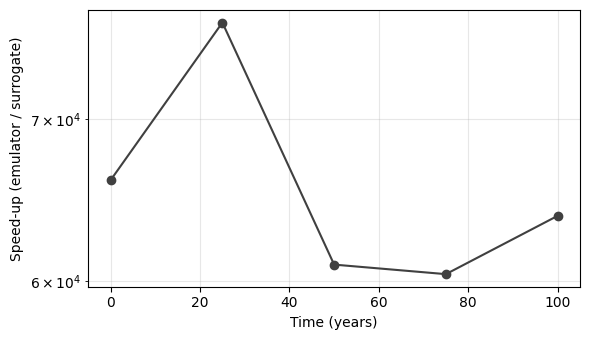

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(speedup['Time (years)'], speedup['Speed-up'], marker='o', color='0.25')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Speed-up (emulator / surrogate)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}x'))
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()